# 8. hv_252 Bates 앵커 vs MC(180일 HV) — 공정가 대비 전량 비교

발행시점 이론가 두 방식을 **실제 공정가(fair)** 와 비교 (전 상품 58,790, as-of):
- **MC 180일 HV** (`mc_hist`): 기존 정본 — GBM(상수 역사변동성 180일) + NS 할인, 40k 경로.
- **hv_252 Bates** (`mc_bates`): 신규 — Heston 스큐(레버리지 ρ, as-of) + Merton 점프(as-of) + hv_252 레벨, 180일 역사상관, NS 할인, 40k 경로.

주의: 두 방식은 **변동성 창(180→252) + 모형(GBM→Bates)** 이 함께 다르므로, 이 비교는 "기존 역사-GBM 앵커 → 신규 Bates 앵커"의 **총 개선폭**이다(성분 분해는 노트북 7 bake-off 참조).

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"savefig.dpi": 400, "savefig.transparent": True, "savefig.bbox": "tight",
                     "figure.figsize": (13.333, 4.8), "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 12, "axes.titleweight": "bold"})
ROOT = Path.cwd(); FACE = 10000; IMG = ROOT / "result/image"
d = pd.read_parquet(ROOT / "data/els3_dataset.parquet")
a = pd.read_csv(ROOT / "result/statistics/anchor_bates_hv252.csv")
cols = ["item", "fair", "mc_hist"] + [c for c in ["opt_type", "ki_yn"] if c in d.columns]
M = d[cols].merge(a[["item", "mc_bates", "ki"]], on="item", how="inner")
M["e_hist"] = (M.fair - M.mc_hist) * FACE; M["e_bates"] = (M.fair - M.mc_bates) * FACE
C_H, C_B = "#e07a5f", "#1f6f9c"
def stat(e): return dict(bias=e.mean(), MAE=e.abs().mean(), RMSE=np.sqrt((e**2).mean()))
sh, sb = stat(M.e_hist), stat(M.e_bates)
print(f"[전량 n={len(M):,}, 공정가 대비 오차 (원/10,000)]")
print(f"  MC 180일 HV   bias {sh['bias']:+7.1f}  MAE {sh['MAE']:7.1f}  RMSE {sh['RMSE']:7.1f}")
print(f"  hv_252 Bates  bias {sb['bias']:+7.1f}  MAE {sb['MAE']:7.1f}  RMSE {sb['RMSE']:7.1f}")
print(f"  개선: MAE {(sb['MAE']/sh['MAE']-1)*100:+.1f}%  bias {(1-sb['bias']/sh['bias'])*100:+.0f}% 축소  RMSE {(sb['RMSE']/sh['RMSE']-1)*100:+.1f}%")

[전량 n=58,790, 공정가 대비 오차 (원/10,000)]
  MC 180일 HV   bias  -556.0  MAE   613.7  RMSE   725.2
  hv_252 Bates  bias  -411.1  MAE   504.1  RMSE   608.3
  개선: MAE -17.9%  bias +26% 축소  RMSE -16.1%


## 1. 오차 분포 · 요약 지표

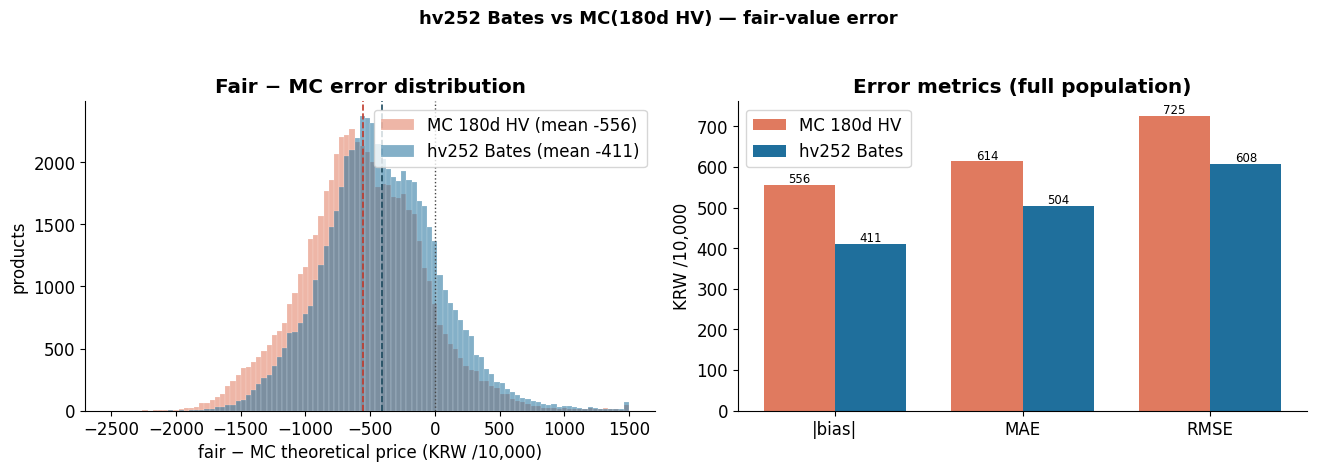

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13.333, 4.8))
ax[0].hist(M.e_hist.clip(-2500, 1500), bins=100, color=C_H, alpha=.55, edgecolor="white", lw=.2, label=f"MC 180d HV (mean {sh['bias']:,.0f})")
ax[0].hist(M.e_bates.clip(-2500, 1500), bins=100, color=C_B, alpha=.55, edgecolor="white", lw=.2, label=f"hv252 Bates (mean {sb['bias']:,.0f})")
ax[0].axvline(0, color="#444", lw=1, ls=":"); ax[0].axvline(sh['bias'], color="#c0392b", lw=1.2, ls="--"); ax[0].axvline(sb['bias'], color="#1c4a5f", lw=1.2, ls="--")
ax[0].set_xlabel("fair − MC theoretical price (KRW /10,000)"); ax[0].set_ylabel("products"); ax[0].set_title("Fair − MC error distribution"); ax[0].legend()
x = np.arange(3); w = 0.38
ax[1].bar(x - w/2, [abs(sh['bias']), sh['MAE'], sh['RMSE']], w, color=C_H, label="MC 180d HV")
ax[1].bar(x + w/2, [abs(sb['bias']), sb['MAE'], sb['RMSE']], w, color=C_B, label="hv252 Bates")
for i, (h, b) in enumerate(zip([abs(sh['bias']), sh['MAE'], sh['RMSE']], [abs(sb['bias']), sb['MAE'], sb['RMSE']])):
    ax[1].text(i - w/2, h + 5, f"{h:.0f}", ha="center", fontsize=8.5); ax[1].text(i + w/2, b + 5, f"{b:.0f}", ha="center", fontsize=8.5)
ax[1].set_xticks(x); ax[1].set_xticklabels(["|bias|", "MAE", "RMSE"]); ax[1].set_ylabel("KRW /10,000"); ax[1].set_title("Error metrics (full population)"); ax[1].legend()
fig.suptitle("hv252 Bates vs MC(180d HV) — fair-value error", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95)); fig.savefig(IMG / "bates_vs_hist_overview.png"); plt.show()

## 2. 가격구간별 · 산점

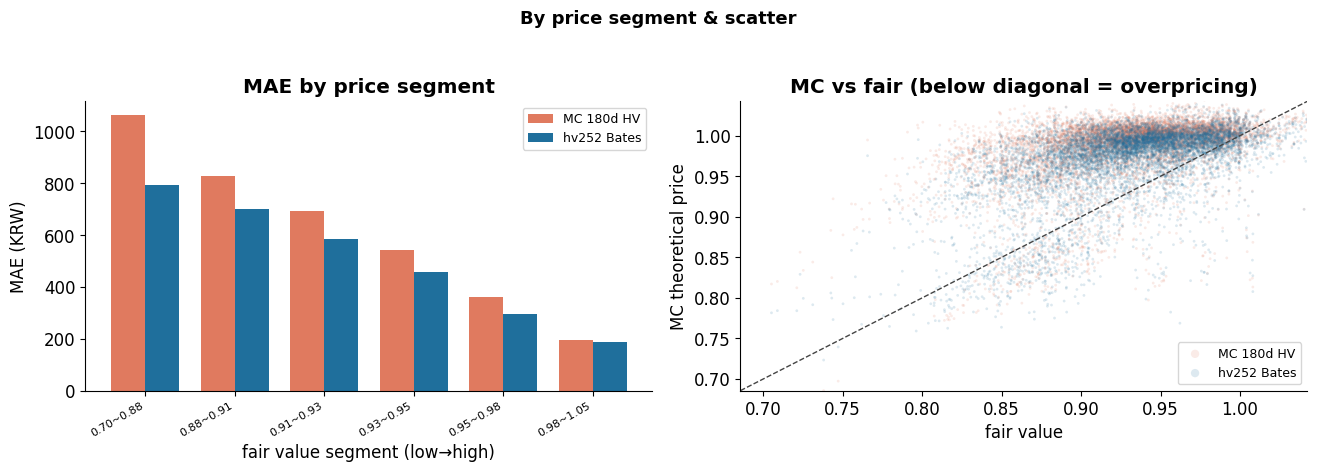

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13.333, 4.8))
seg = pd.qcut(M.fair, 6); xs = np.arange(6); w = 0.38
gh = M.groupby(seg, observed=True).e_hist.agg(["mean", lambda s: s.abs().mean()]); gh.columns = ["bias", "mae"]
gb = M.groupby(seg, observed=True).e_bates.agg(["mean", lambda s: s.abs().mean()]); gb.columns = ["bias", "mae"]
ax[0].bar(xs - w/2, gh.mae, w, color=C_H, label="MC 180d HV"); ax[0].bar(xs + w/2, gb.mae, w, color=C_B, label="hv252 Bates")
ax[0].set_xticks(xs); ax[0].set_xticklabels([f"{i.left:.2f}~{i.right:.2f}" for i in gh.index], rotation=30, fontsize=8, ha="right")
ax[0].set_xlabel("fair value segment (low→high)"); ax[0].set_ylabel("MAE (KRW)"); ax[0].set_title("MAE by price segment"); ax[0].legend(fontsize=9)
s = M.sample(min(8000, len(M)), random_state=0)
lim = [min(s.mc_hist.min(), s.fair.min()), max(s.mc_hist.quantile(.999), s.fair.quantile(.999))]
ax[1].scatter(s.fair, s.mc_hist, s=4, alpha=.15, color=C_H, edgecolors="none", label="MC 180d HV")
ax[1].scatter(s.fair, s.mc_bates, s=4, alpha=.15, color=C_B, edgecolors="none", label="hv252 Bates")
ax[1].plot(lim, lim, "--", color="#444", lw=1); ax[1].set_xlim(lim); ax[1].set_ylim(lim)
ax[1].set_xlabel("fair value"); ax[1].set_ylabel("MC theoretical price"); ax[1].set_title("MC vs fair (below diagonal = overpricing)"); ax[1].legend(fontsize=9, markerscale=3)
fig.suptitle("By price segment & scatter", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95)); fig.savefig(IMG / "bates_vs_hist_segment.png"); plt.show()

## 3. 구조별 (STEP/LIZARD × 낙인)

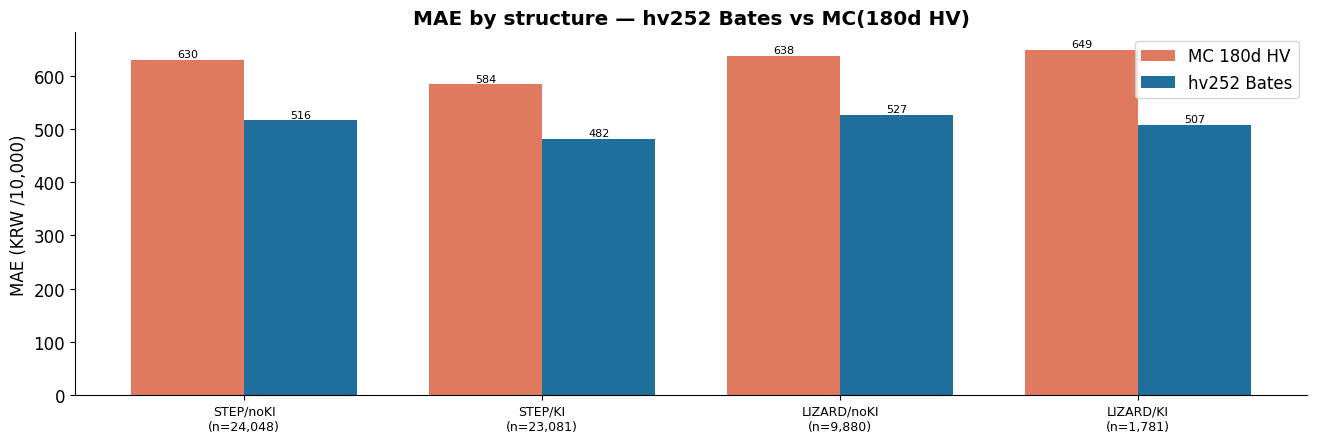

                 n  mae_h  mae_b
struct                          
STEP/noKI    24048  630.1  516.3
STEP/KI      23081  583.6  481.5
LIZARD/noKI   9880  637.7  526.7
LIZARD/KI     1781  648.8  507.1


In [4]:
if "opt_type" in M.columns:
    M["struct"] = M["opt_type"].astype(str) + ("/KI" if "ki_yn" not in M.columns else "")
    if "ki_yn" in M.columns:
        M["struct"] = M["opt_type"].astype(str) + np.where(M["ki_yn"].astype(str).isin(["Y", "1", "True", "y"]), "/KI", "/noKI")
    g = M.groupby("struct").agg(n=("fair", "size"), mae_h=("e_hist", lambda s: s.abs().mean()), mae_b=("e_bates", lambda s: s.abs().mean())).sort_values("n", ascending=False)
    fig, ax = plt.subplots(figsize=(13.333, 4.6)); xs = np.arange(len(g)); w = 0.38
    ax.bar(xs - w/2, g.mae_h, w, color=C_H, label="MC 180d HV"); ax.bar(xs + w/2, g.mae_b, w, color=C_B, label="hv252 Bates")
    ax.set_xticks(xs); ax.set_xticklabels([f"{i}\n(n={int(n):,})" for i, n in zip(g.index, g.n)], fontsize=9)
    for i, (h, b) in enumerate(zip(g.mae_h, g.mae_b)): ax.text(i - w/2, h + 5, f"{h:.0f}", ha="center", fontsize=8); ax.text(i + w/2, b + 5, f"{b:.0f}", ha="center", fontsize=8)
    ax.set_ylabel("MAE (KRW /10,000)"); ax.set_title("MAE by structure — hv252 Bates vs MC(180d HV)"); ax.legend()
    fig.tight_layout(); fig.savefig(IMG / "bates_vs_hist_structure.png"); plt.show()
    print(g.round(1).to_string())
else:
    print("opt_type 없음 — 구조별 생략")

## 4. 결론

- **hv_252 Bates 앵커가 기존 MC(180일 HV)보다 공정가 오차를 전량 기준 크게 줄인다**: MAE 614→504원(−18%), 과대평가 편향 −556→−411원(−26% 축소), RMSE 725→608원.
- 개선 원천(노트북 7 bake-off 분해): (1) 더 긴 변동성 창으로 레벨 상향, (2) Heston 레버리지 스큐 + Merton 점프로 worst-of 하방/KI 반영 → 이론가를 낮춰 과대평가 축소.
- **다만 −411원 과대평가는 잔존** = 위험프리미엄(P→Q 갭). 이는 발행시점 실현/역사 기반(P측도) 입력의 한계이며, 서피스-MFIV(Q, 차단) 또는 **stage-2 잔차모델의 IV 피처 학습**으로 보정 대상(노트북/계획 §9).